In [23]:
from model_ranking import (
    load_h5,
    save_h5,
    get_roi_slice,
    get_random_colors,
)
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from pytorch3dunet.augment.transforms import Relabel

In [4]:
ov_gt_path = "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5"
label_key = "label_with_ignore"
raw_key = "raw"

ov_gt = load_h5(ov_gt_path, label_key)
ov_raw = load_h5(ov_gt_path, raw_key)
print(ov_gt.shape, ov_raw.shape)

(320, 960, 1000) (320, 960, 1000)


# fw_model_Unet2

In [3]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P_full/fw_model_Unet2/norm_50_950"
paths = list(Path(base_path).rglob("**/predictions/N_294_final_crop_ds2_predictions.h5"))
print(len(paths))

6


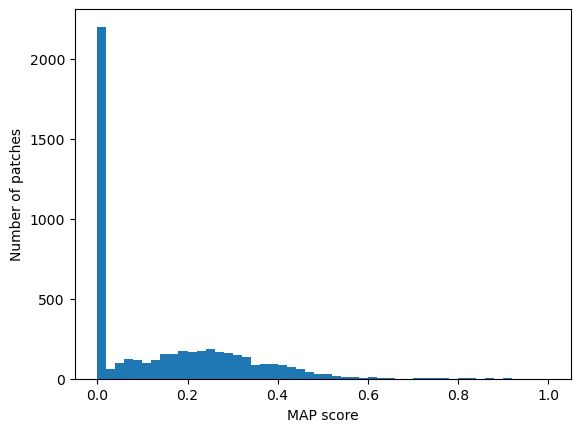

In [19]:
NA_path = paths[0]
MAP_scores = load_h5(NA_path, "MAP_05_095")
patch_indexes = load_h5(NA_path, "patch_index")
preds = load_h5(NA_path, "predictions")

plt.hist(MAP_scores, bins=50)
plt.xlabel("MAP score")
plt.ylabel("Number of patches")
plt.show()

In [20]:
preds.shape

(5120, 1, 1, 256, 256)

In [21]:
patchwise_gt = np.zeros_like(preds.squeeze(), dtype=np.int16)
for i in range(patch_indexes.shape[0]):
    sl = get_roi_slice(patch_indexes[i])
    patchwise_gt[i] = ov_gt[sl].squeeze()

In [25]:
patchwise_raw = np.zeros_like(preds.squeeze(), dtype=np.float32)
for i in range(patch_indexes.shape[0]):
    sl = get_roi_slice(patch_indexes[i])
    patchwise_raw[i] = ov_raw[sl].squeeze()

In [ ]:
# save_path = "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2_patchwise.h5"
# save_h5(save_path, "raw", patchwise_raw, overwrite=False)

In [22]:
patchwise_gt.shape

(5120, 256, 256)

In [6]:
ids_sup_03 = np.where(MAP_scores > 0.3)[0]
print(len(ids_sup_03))

956


(5120, 3)


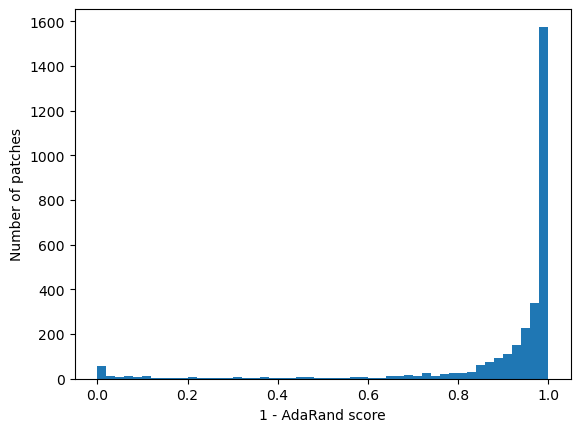

In [11]:
AdaRand_scores = load_h5(paths[3], "AdaRandError_consis")
print(AdaRand_scores.shape)
plt.hist(1 - AdaRand_scores[:,0], bins=50)
plt.xlabel("1 - AdaRand score")
plt.ylabel("Number of patches")
plt.show()

In [12]:
ids_ARE_1 = np.where((1 - AdaRand_scores[:,0]) == 1)[0]
print(len(ids_ARE_1))

725


In [18]:
paths[0]

PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P_full/fw_model_Unet2/norm_50_950/none/predictions/N_294_final_crop_ds2_predictions.h5')

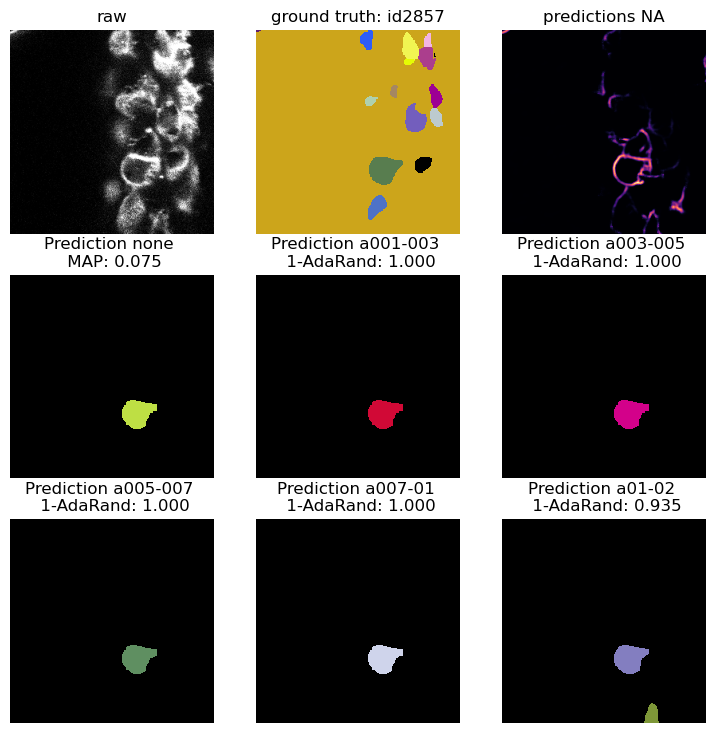

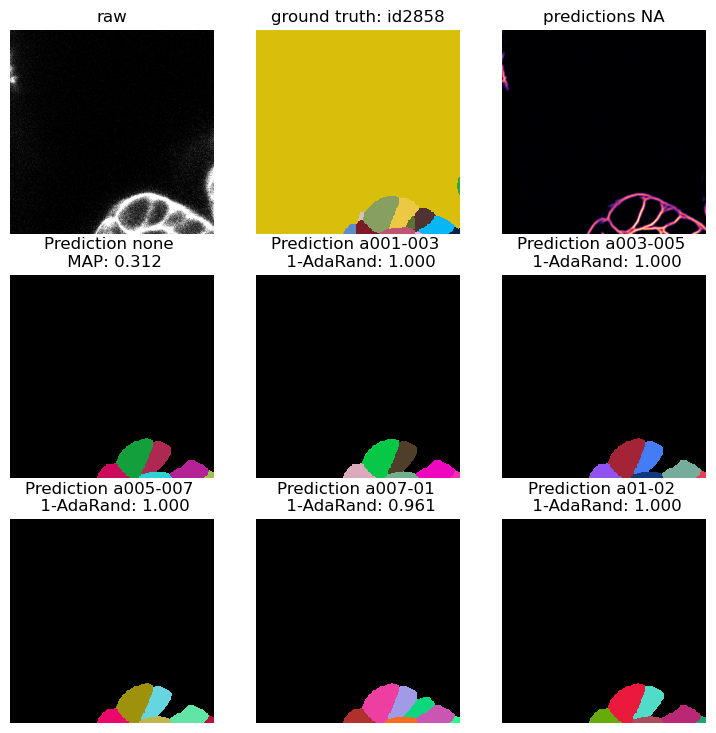

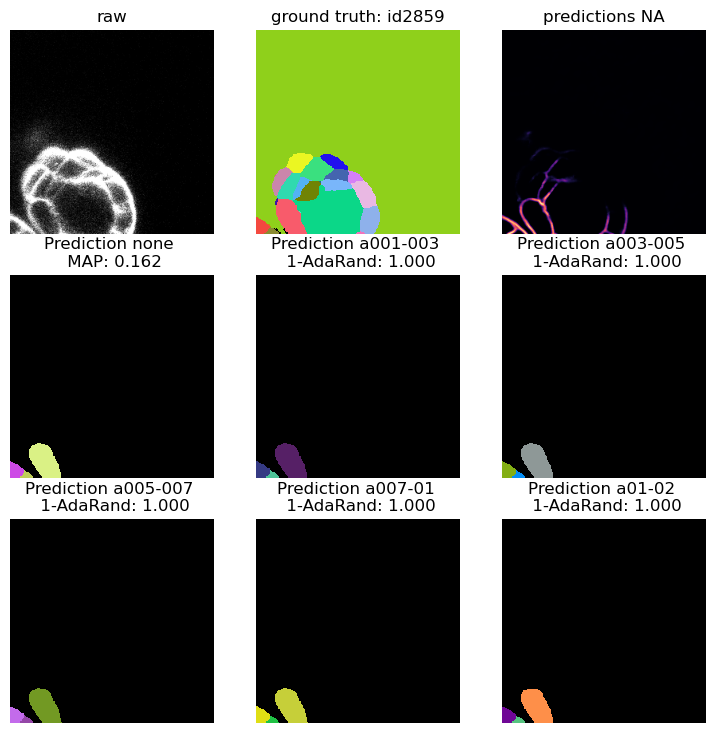

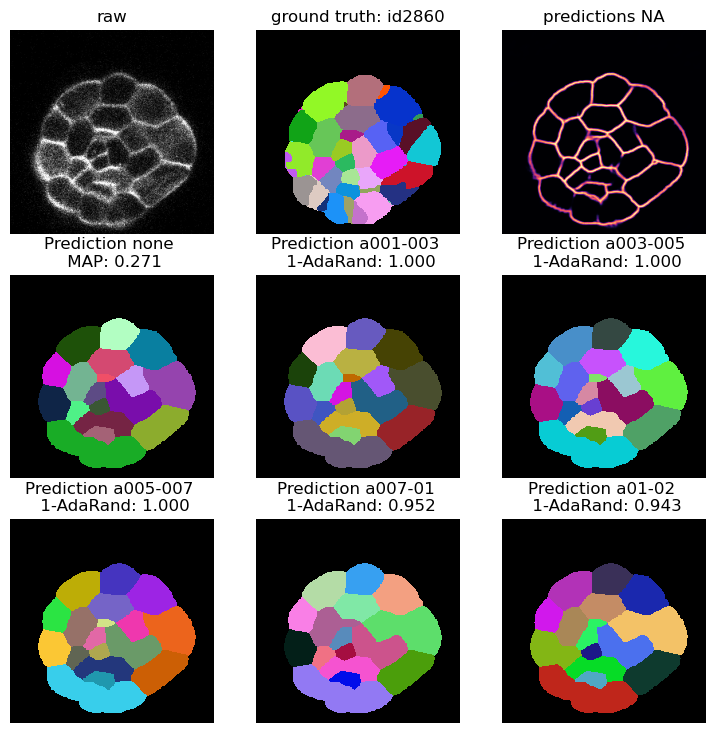

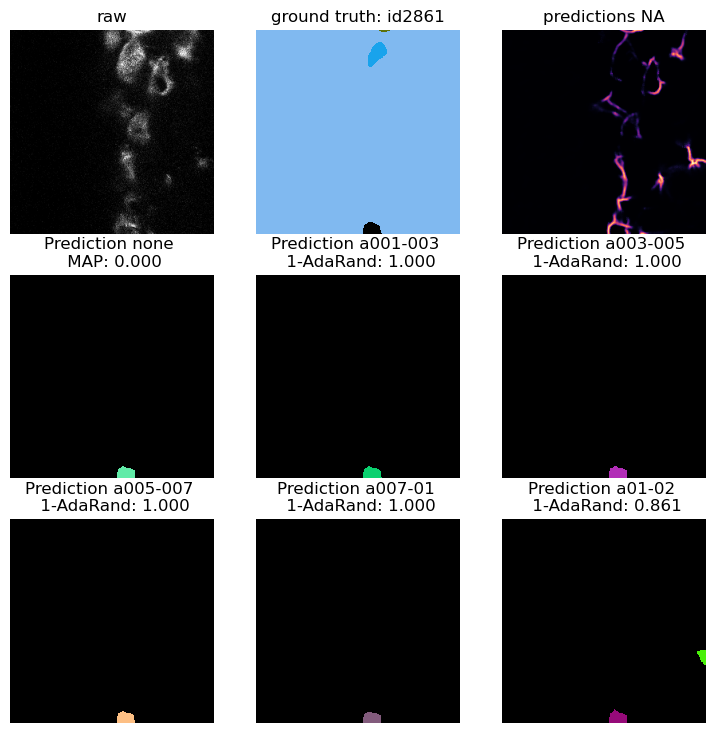

In [17]:
num_samples = 5
offset = 300
selected_augs = ["none", "a001-003", 'a003-005', 'a005-007', 'a007-01', 'a01-02']
# rng = np.random.default_rng(42)
# rng.shuffle(ids_sub_04)

for i in ids_ARE_1[offset:offset + num_samples]:
    patch_roi = get_roi_slice(patch_indexes[i])
    raw = ov_raw[patch_roi].squeeze()
    label = ov_gt[patch_roi].squeeze()
    label = Relabel(append_original = True, ignore_label=-1)(label)
    _, axs = plt.subplots(3,3, figsize=(9,9))
    axs = axs.flatten()
    axs[0].imshow(raw, cmap='gray')
    axs[0].set_title("raw")
    axs[0].axis('off')
    axs[1].imshow(label[0], cmap=get_random_colors(label[0]), interpolation='nearest')
    axs[1].set_title(f"ground truth: id{i}")
    axs[1].axis('off')
    axs[2].imshow(load_h5(paths[0], "predictions", select_index=i).squeeze(), cmap='magma')
    axs[2].set_title(f"predictions NA")
    axs[2].axis('off')
    for j, path in enumerate(paths):
        assert selected_augs[j] in str(path)
        preds_temp = load_h5(path, "segmentation", select_index=i)
        axs[3+j].imshow(preds_temp.squeeze(), cmap=get_random_colors(preds_temp), interpolation='nearest')
        if "none" not in str(path):
            AdaRand_score = 1 - load_h5(path, "AdaRandError_consis", select_index=i)[0]
            axs[3+j].set_title(f"Prediction {selected_augs[j]} \n 1-AdaRand: {AdaRand_score:.3f}")
        else:
            axs[3+j].set_title(f"Prediction {selected_augs[j]} \n MAP: {MAP_scores[i]:.3f}")
        axs[3+j].axis('off')
    plt.show()